# 03 — Baseline Teks: MLP vs CNN1D

Tahap 5A. **Belum pernah dijalankan** di mesin penulis kode — tidak ada dataset
maupun fitur hasil Tahap 4. Jalankan di mesin compute.

Replikasi Tabel 1a paper (MLP 70,8% / CNN 1D 73,9%) dan baris TEXT Tabel 3 (73,8%).

**Prasyarat:** `02_text_features.ipynb` sudah dijalankan, sehingga ada
`sequences_500x300_fp16.npy`, `sif_seed*.npy`, dan `split_seed*.json`.

Hyperparameter dari paper §4.2: SGD momentum 0,9, lr 0,01, batch 40, 100 epoch.
Early stopping adalah tambahan kita, bukan bagian paper.

In [1]:
import sys, json, time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch

from src import datasets as DS
from src import splits as S
from src import train as T
from src.config import CONFIG, set_seed
from src.utils import save_fig

manifest = pd.read_csv(CONFIG["data_processed"] / "manifest.csv")
labels = manifest["kelas"].tolist()
y = DS.label_indices(labels)
device = T.pick_device()
print(f"{len(manifest)} dokumen | device: {device}")

3482 dokumen | device: cuda


## 1. Estimasi durasi lebih dulu

Aturan ">15 menit tanya dulu" tidak berguna kalau tidak ada yang mengukur. Sel ini
menjalankan 2 epoch untuk mendapat detik/epoch nyata, lalu mengekstrapolasi ke
target 100 epoch.

In [2]:
from src.models import CNN1D, MLP

set_seed(42)
split = S.load_split(42, labels)
seq_path = CONFIG["data_processed"] / "sequences_500x300_fp16.npy"

loaders_cnn = DS.make_loaders(
    lambda idx: DS.SequenceDataset(seq_path, y, idx), split)
loaders_mlp = DS.make_loaders(
    lambda idx: DS.VectorDataset(CONFIG["data_processed"] / "sif_seed42.npy", y, idx),
    split)

for nama, model, loaders in [("MLP", MLP(), loaders_mlp),
                             ("CNN1D", CNN1D(), loaders_cnn)]:
    est = T.estimate_duration(model, loaders, CONFIG["epochs"]["text"], device=device)
    print(f"{nama}: {est['detik_per_epoch']}s/epoch -> "
          f"{est['perkiraan_menit']} menit untuk {est['target_epochs']} epoch "
          f"({est['device']})")

MLP: 0.7025s/epoch -> 1.17 menit untuk 100 epoch (cuda)
CNN1D: 2.5675s/epoch -> 4.28 menit untuk 100 epoch (cuda)


Kalau estimasi di atas terlalu lama, turunkan `EPOCHS` di sel berikut dan
**catat pemotongannya sebagai deviasi** di catatan eksperimen. Jangan dipotong
diam-diam.

In [3]:
EPOCHS = CONFIG["epochs"]["text"]   # 100 sesuai paper; turunkan bila perlu
DEVIASI_EPOCH = EPOCHS != CONFIG["epochs"]["text"]
print(f"akan melatih {EPOCHS} epoch"
      + ("  <-- DEVIASI, catat di catatan!" if DEVIASI_EPOCH else ""))

akan melatih 100 epoch


## 2. Latih kedua model, tiga seed

Paper merata-ratakan atas 3 run. Kita memakai tiga split berbeda (seed 42/43/44),
yang merupakan deviasi dari k-fold paper.

In [4]:
def ringkas(nama, hasil_per_seed):
    """Cetak blok siap-salin untuk catatan eksperimen, satu baris per seed."""
    df = pd.DataFrame(hasil_per_seed)
    print(f"=== {nama} ===")
    print(df.to_string(index=False))
    print(f"\nOA       {df['oa'].mean():.4f} +/- {df['oa'].std(ddof=0):.4f}")
    print(f"macro F1 {df['macro_f1'].mean():.4f} +/- {df['macro_f1'].std(ddof=0):.4f}")
    print(f"\nUntuk frontmatter catatan (rata-rata 3 seed):")
    print(f"oa:: {df['oa'].mean():.4f}")
    print(f"macro_f1:: {df['macro_f1'].mean():.4f}")
    print(f"durasi:: {df['durasi_detik'].sum() / 60:.1f} menit total")
    return df

In [5]:
def jalankan(nama_model, buat_model, buat_dataset, epochs):
    hasil, prediksi = [], {}
    for seed in CONFIG["seeds"]:
        set_seed(seed)
        sp = S.load_split(seed, labels)
        loaders = DS.make_loaders(lambda idx: buat_dataset(seed, idx), sp)
        model = buat_model()

        print(f"\n[{nama_model} seed {seed}]")
        res = T.train_model(
            model, loaders, epochs=epochs, device=device,
            log_csv=CONFIG["root"] / "reports" / f"log_{nama_model}_seed{seed}.csv",
            ckpt_path=CONFIG["models"] / f"{nama_model}_seed{seed}.pt")
        ev = T.evaluate(model, loaders["test"], device)

        hasil.append({"seed": seed, "oa": round(ev["oa"], 4),
                      "macro_f1": round(ev["macro_f1"], 4),
                      "epoch_terbaik": res["best_epoch"],
                      "epoch_dijalankan": res["epochs_run"],
                      "durasi_detik": res["durasi_detik"]})
        prediksi[seed] = ev
    return hasil, prediksi

In [6]:
hasil_mlp, pred_mlp = jalankan(
    "MLP", MLP,
    lambda seed, idx: DS.VectorDataset(
        CONFIG["data_processed"] / f"sif_seed{seed}.npy", y, idx),
    EPOCHS)
df_mlp = ringkas("MLP (SIF document embedding)", hasil_mlp)


[MLP seed 42]
  epoch   1/100  train_loss 2.4654  val_oa 0.4125  (0.6s)
  epoch  10/100  train_loss 1.0854  val_oa 0.6125  (0.4s)
  epoch  20/100  train_loss 0.7869  val_oa 0.6125  (0.4s)
  epoch  30/100  train_loss 0.6136  val_oa 0.6500  (0.4s)
  epoch  40/100  train_loss 0.6019  val_oa 0.6375  (0.4s)
  early stopping di epoch 47; terbaik epoch 32

[MLP seed 43]
  epoch   1/100  train_loss 2.6184  val_oa 0.5000  (0.3s)
  epoch  10/100  train_loss 1.1794  val_oa 0.6875  (0.4s)
  epoch  20/100  train_loss 0.8117  val_oa 0.6750  (0.3s)
  epoch  30/100  train_loss 0.7183  val_oa 0.6875  (0.3s)
  early stopping di epoch 36; terbaik epoch 21

[MLP seed 44]
  epoch   1/100  train_loss 2.5292  val_oa 0.4125  (0.3s)
  epoch  10/100  train_loss 1.1170  val_oa 0.5875  (0.3s)
  epoch  20/100  train_loss 0.8038  val_oa 0.6000  (0.3s)
  epoch  30/100  train_loss 0.6445  val_oa 0.6000  (0.5s)
  early stopping di epoch 37; terbaik epoch 22
=== MLP (SIF document embedding) ===
 seed     oa  macro_f1 

In [7]:
hasil_cnn, pred_cnn = jalankan(
    "CNN1D", CNN1D,
    lambda seed, idx: DS.SequenceDataset(seq_path, y, idx),
    EPOCHS)
df_cnn = ringkas("CNN1D (word sequence)", hasil_cnn)


[CNN1D seed 42]
  epoch   1/100  train_loss 2.2893  val_oa 0.1750  (2.2s)
  epoch  10/100  train_loss 0.9367  val_oa 0.5375  (2.1s)
  epoch  20/100  train_loss 0.2254  val_oa 0.7375  (2.1s)
  epoch  30/100  train_loss 0.0434  val_oa 0.7375  (2.2s)
  epoch  40/100  train_loss 0.0132  val_oa 0.7375  (2.2s)
  early stopping di epoch 43; terbaik epoch 28

[CNN1D seed 43]
  epoch   1/100  train_loss 2.2770  val_oa 0.2000  (2.2s)
  epoch  10/100  train_loss 0.7925  val_oa 0.5250  (2.2s)
  epoch  20/100  train_loss 0.2435  val_oa 0.6750  (2.2s)
  epoch  30/100  train_loss 0.0557  val_oa 0.7625  (2.2s)
  epoch  40/100  train_loss 0.0188  val_oa 0.7750  (2.2s)
  early stopping di epoch 40; terbaik epoch 25

[CNN1D seed 44]
  epoch   1/100  train_loss 2.3054  val_oa 0.2000  (2.3s)
  epoch  10/100  train_loss 1.0372  val_oa 0.6875  (2.2s)
  epoch  20/100  train_loss 0.2349  val_oa 0.6000  (2.3s)
  epoch  30/100  train_loss 0.0291  val_oa 0.7000  (2.2s)
  epoch  40/100  train_loss 0.0445  val_oa 

## 3. Perbandingan dengan paper

Paper Tabel 1a: MLP 70,8% / 0,69, CNN 1D 73,9% / 0,71. Tabel 3 TEXT: 73,8% / 0,71.

Yang harus konsisten adalah **urutannya** (CNN1D di atas MLP), bukan angka
persisnya. Selisih 2-4% wajar mengingat framework berbeda, split berbeda, dan
sumber citra berbeda.

In [8]:
banding = pd.DataFrame([
    {"model": "MLP",   "oa_kita": df_mlp["oa"].mean(),  "oa_paper": 0.708,
     "f1_kita": df_mlp["macro_f1"].mean(),  "f1_paper": 0.69},
    {"model": "CNN1D", "oa_kita": df_cnn["oa"].mean(),  "oa_paper": 0.739,
     "f1_kita": df_cnn["macro_f1"].mean(),  "f1_paper": 0.71},
])
banding["selisih_oa"] = (banding["oa_kita"] - banding["oa_paper"]).round(4)
display(banding.round(4))

menang = df_cnn["oa"].mean() > df_mlp["oa"].mean()
print(f"\nCNN1D mengalahkan MLP seperti paper? {menang}")
if not menang:
    print("TEMUAN NEGATIF terhadap paper — jangan dibulatkan jadi 'berhasil'.")
    print("Periksa dulu: apakah SIF PCA dipasang pada train saja? Apakah sekuens "
          "ter-truncate terlalu agresif? Baru laporkan sebagai temuan.")

,model,oa_kita,oa_paper,f1_kita,f1_paper,selisih_oa
0,MLP,0.6780,0.708,0.6616,0.69,-0.0300
1,CNN1D,0.7266,0.739,0.7017,0.71,-0.0124



CNN1D mengalahkan MLP seperti paper? True


## 4. Confusion matrix dan laporan per kelas

Model TEXT dipakai sebagai cabang teks di Tahap 6, jadi pola kesalahannya penting:
kelas yang kuat di teks tapi lemah di citra itulah sumber komplementaritas.

Paper melaporkan TEXT unggul jauh di **Resume** (0,97 vs 0,80 untuk citra).

               precision    recall  f1-score   support

Advertisement      0.553     0.616     0.583       177
        Email      0.946     0.948     0.947       461
         Form      0.650     0.834     0.731       332
       Letter      0.717     0.689     0.702       437
         Memo      0.760     0.780     0.770       478
         News      0.737     0.676     0.705       145
         Note      0.564     0.684     0.618       155
       Report      0.560     0.500     0.528       204
       Resume      0.988     0.924     0.955        92
   Scientific      0.845     0.408     0.550       201

     accuracy                          0.735      2682
    macro avg      0.732     0.706     0.709      2682
 weighted avg      0.744     0.735     0.731      2682



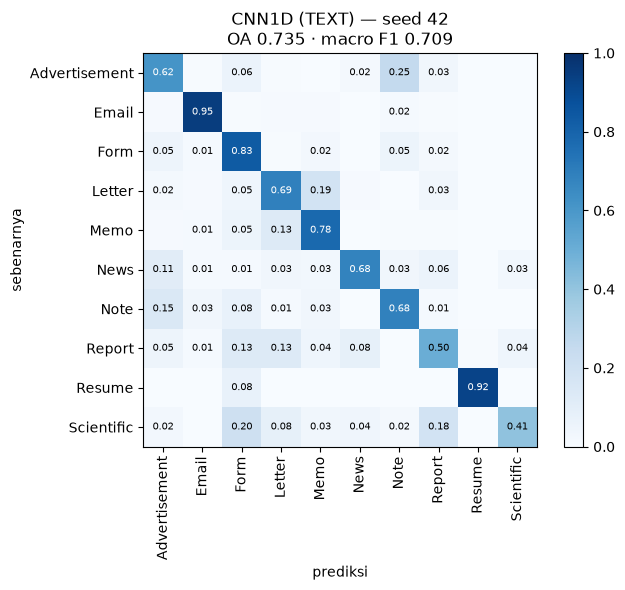

In [9]:
ev = pred_cnn[42]
fig = T.plot_confusion(ev, "CNN1D (TEXT) — seed 42")
save_fig(fig, "05_confusion_text_cnn1d_seed42")
print(T.report(ev))

In [10]:
# F1 per kelas, tiga seed, untuk dibandingkan baris TEXT Tabel 3 paper.
from sklearn.metrics import f1_score

per_kelas = pd.DataFrame(
    {seed: f1_score(e["y_true"], e["y_pred"], average=None,
                    labels=range(len(CONFIG["classes"])), zero_division=0)
     for seed, e in pred_cnn.items()}, index=CONFIG["classes"])
per_kelas["rata2"] = per_kelas.mean(axis=1)
per_kelas["paper_TEXT"] = [0.60, 0.96, 0.76, 0.71, 0.79, 0.67, 0.62, 0.43, 0.97, 0.57]
display(per_kelas.round(3))

# Simpan prediksi SETIAP seed: oracle di Tahap 6 dihitung per seed, jadi seed 42
# saja tidak cukup untuk melaporkan rata-rata +/- std.
for seed, e in pred_cnn.items():
    np.save(CONFIG["data_processed"] / f"pred_text_seed{seed}.npy",
            np.stack([e["y_true"], e["y_pred"]]))
print("\nPrediksi TEXT per seed disimpan — Tahap 6 membutuhkannya untuk oracle.")

,42,43,44,rata2,paper_TEXT
Advertisement,0.583,0.502,0.526,0.537,0.60
Email,0.947,0.958,0.955,0.953,0.96
Form,0.731,0.708,0.714,0.718,0.76
Letter,0.702,0.662,0.647,0.671,0.71
Memo,0.770,0.778,0.726,0.758,0.79
News,0.705,0.708,0.715,0.709,0.67
Note,0.618,0.604,0.640,0.621,0.62
Report,0.528,0.473,0.484,0.495,0.43
Resume,0.955,0.978,0.973,0.969,0.97
Scientific,0.550,0.625,0.587,0.587,0.57



Prediksi TEXT per seed disimpan — Tahap 6 membutuhkannya untuk oracle.


## 5. Ringkasan untuk catatan eksperimen

Buat **satu catatan per run** di `vault/30-eksperimen/`, bukan satu catatan untuk
semuanya. Isi `oa::`, `macro_f1::`, dan `durasi::` dari angka di bawah.

In [11]:
for nama, df in [("MLP", df_mlp), ("CNN1D", df_cnn)]:
    print(f"\n----- {nama} -----")
    for _, r in df.iterrows():
        print(f"seed {int(r['seed'])}: oa:: {r['oa']}  macro_f1:: {r['macro_f1']}  "
              f"durasi:: {r['durasi_detik']}s  "
              f"(epoch terbaik {int(r['epoch_terbaik'])}/"
              f"{int(r['epoch_dijalankan'])})")
    print(f"rata-rata: oa:: {df['oa'].mean():.4f}  "
          f"macro_f1:: {df['macro_f1'].mean():.4f}")
print(f"\nEPOCHS dijalankan: {EPOCHS} (paper: {CONFIG['epochs']['text']})")
print("DEVIASI epoch:", DEVIASI_EPOCH)


----- MLP -----
seed 42: oa:: 0.6779  macro_f1:: 0.6628  durasi:: 21.2s  (epoch terbaik 32/47)
seed 43: oa:: 0.682  macro_f1:: 0.6577  durasi:: 13.05s  (epoch terbaik 21/36)
seed 44: oa:: 0.6741  macro_f1:: 0.6644  durasi:: 13.624s  (epoch terbaik 22/37)
rata-rata: oa:: 0.6780  macro_f1:: 0.6616

----- CNN1D -----
seed 42: oa:: 0.7345  macro_f1:: 0.709  durasi:: 92.164s  (epoch terbaik 28/43)
seed 43: oa:: 0.7248  macro_f1:: 0.6994  durasi:: 88.903s  (epoch terbaik 25/40)
seed 44: oa:: 0.7204  macro_f1:: 0.6967  durasi:: 103.253s  (epoch terbaik 31/46)
rata-rata: oa:: 0.7266  macro_f1:: 0.7017

EPOCHS dijalankan: 100 (paper: 100)
DEVIASI epoch: False
